### ENV Vars


In [44]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
db_endpoint = os.getenv("ASTRA_DB_ENDPOINT")
token = os.getenv("ASTRA_DB_APPLICATION_TOKEN")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

### Astra DB Setup


In [45]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_astradb import AstraDBVectorStore

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12730.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [46]:
db = AstraDBVectorStore(
    collection_name="agent_db",
    embedding=embeddings,
    api_endpoint=db_endpoint,
    token=token,
)

### Build Astra DB


In [47]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
doc_list = [item for sublist in docs for item in sublist]
splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
texts = splitter.split_documents(doc_list)

In [48]:
db.add_documents(texts)

['b5e7d2c8994d46e0a30170eefb2fad86',
 'a20455485ba1404c938fe1d94b4f9486',
 '453a51224890469f9be4a13e10af1dec',
 '00958025db5c461a916107304549dbd5',
 'ee7c46a589c849ff8206968186de040e',
 'ab236f507c424e789a168672a52c715a',
 'f9e43de04fe0416cb2fb71cab87a88aa',
 '6af75d8140f4439daf19e0337361a859',
 'ff5f829fbf8149a2808eaa0ac9e2ae8f',
 'c0da1e522e264879b0e62d5554272979',
 'cd07560101ef4b0c9a7b6f201083f955',
 '28afc81dda1f44588520e9cd6b75d780',
 '10d02b2f3034454fa0086c813f97cf70',
 '4c08b949a47141d3b9641cc0bb2cee22',
 '224a31dd470a46d09ef0fde0bc39d2b4',
 'bcfca8513c0440629803f2f1cd7af900',
 '199048dddbe84c349823d809e199331c',
 '6f078c1284534cbfaf2558a65ec1c1b0',
 'ad176d71de55410ebec78fea3443fd6d',
 'e2262e1a03ac4ddea479c2a31a390c7f',
 '108d887ed51f4885ac679fbbe4bef1e3',
 '616859f84fc4489bab0d07eed357bb6f',
 '14c18b37dcbb4271aed3d63e46657a67',
 '4a16faa9a86143b6939509e0188c0d90',
 '31c1da8483ed42c3a5d0fa946b891065',
 '365f20fad3a64fe5a41e5832b05fabdb',
 '9ead2b03719c464fbb9c21a94a97f7c4',
 

In [49]:
retriever = db.as_retriever()
retriever.invoke("What is agent")

[Document(id='2304106340fe476f9d453830930222f2', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, ther

### Wiki Search Tool


In [50]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic.v1 import BaseModel, Field

In [51]:
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource"""

    datasource: Literal["vectorstore", "wiki_search"] = Field(
        ...,
        description="Given a user question choose to route it to wikipedia or a vectorstore",
    )

In [52]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", groq_api_key=GROQ_API_KEY)

In [53]:
structured_llm_router = llm.with_structured_output(RouteQuery)

In [54]:
system = """You are an expert at routing a user question to a vectorstore or wikipedia.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use wiki-search."""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)


In [55]:
ques_router = route_prompt | structured_llm_router

In [56]:
print(ques_router.invoke({"question": "What is an agent?"}))

datasource='vectorstore'


In [57]:
print(ques_router.invoke({"question": "What is an Gen AI?"}))

datasource='wiki_search'


In [58]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

wiki = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=250)
)

## AI Agent with Langgraph


In [59]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[str]

In [60]:
from langchain_classic.schema import Document


def retrieve(state: GraphState):
    print("--- Retrieve ---")
    questions = state["question"]
    docs = retriever.invoke(questions)
    return {
        "documents": docs,
        "question": questions,
    }

In [61]:
def wiki_search(state: GraphState):
    print("--- Retrieve ---")
    questions = state["question"]
    docs = wiki.invoke(questions)
    results = Document(page_content=docs)
    return {
        "documents": results,
        "question": questions,
    }

In [62]:
def route_question(state: GraphState):
    question = state["question"]
    source = ques_router.invoke({"question": question})
    if source.datasource == "wiki_search":
        print("-- Route Question to Wiki Search --")
        return "wiki_search"
    elif source.datasource == "vectorstore":
        print("-- Route Question to Astra DB --")
        return "vectorstore"


In [63]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(GraphState)

In [64]:
workflow.add_node("wiki_search", wiki_search)
workflow.add_node("retrieve", retrieve)
workflow.add_conditional_edges(
    START, route_question, {"wiki_search": "wiki_search", "vectorstore": "retrieve"}
)
workflow.add_edge("retrieve", END)
workflow.add_edge("wiki_search", END)

In [65]:
app = workflow.compile()

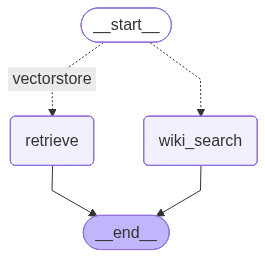

In [66]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [67]:
from pprint import pprint
inputs = {
    "question": "What is agent?"
}
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    pprint("\n---\n")

# Final generation
pprint(value['documents'][0].dict()['metadata']['description'])

-- Route Question to Astra DB --
--- Retrieve ---
"Node 'retrieve':"
'\n---\n'
('Building agents with LLM (large language model) as its core controller is a '
 'cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer '
 'and BabyAGI, serve as inspiring examples. The potentiality of LLM extends '
 'beyond generating well-written copies, stories, essays and programs; it can '
 'be framed as a powerful general problem solver.\n'
 'Agent System Overview\n'
 'In a LLM-powered autonomous agent system, LLM functions as the agent’s '
 'brain, complemented by several key components:\n'
 '\n'
 'Planning\n'
 '\n'
 'Subgoal and decomposition: The agent breaks down large tasks into smaller, '
 'manageable subgoals, enabling efficient handling of complex tasks.\n'
 'Reflection and refinement: The agent can do self-criticism and '
 'self-reflection over past actions, learn from mistakes and refine them for '
 'future steps, thereby improving the quality of final results.\n'
 '\n'

C:\Users\Prashant\AppData\Local\Temp\ipykernel_2868\1781288986.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  pprint(value['documents'][0].dict()['metadata']['description'])


In [69]:
from pprint import pprint
inputs = {
    "question": "What is Avengers?"
}
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    pprint("\n---\n")

# Final generation
pprint(value['documents'])

-- Route Question to Wiki Search --
--- Retrieve ---
"Node 'wiki_search':"
'\n---\n'
Document(metadata={}, page_content='Page: Avengers: Doomsday\nSummary: Avengers: Doomsday is an upcoming American superhero film based on the Marvel Comics superhero team the Avengers. Produced by Marvel Studios and AGBO, and distributed by Walt Disney Studios Motion Pictures, it is int')
